# FGSM & Sparse FGSM Attack (Local WSL Version)

In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# 將本地路徑加入 sys.path 以載入自定義模組
sys.path.append(os.path.abspath('./mnist'))

from fgsm_attack import FGSMAttack, SparseFGSMAttack
from models.mnist_net import mnistNet

In [2]:
def get_device():
    """取得最佳運算裝置 (CUDA 或 CPU)"""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model_path, device):
    """載入模型與權重"""
    print(f"Loading model from {model_path}...")
    model = mnistNet().to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Model loaded successfully.")
    else:
        print("Warning: Model file not found, using uninitialized weights.")
    model.eval()
    return model

def get_test_dataloader(data_path='./mnist/data', batch_size=512):
    """載入 MNIST 測試集並優化傳輸效能"""
    t = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST(data_path, train=False, download=True, transform=t)
    
    dataloader = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        num_workers=4,      # 使用 4 個 CPU 線程準備數據
        pin_memory=True,    # 加速將數據從記憶體搬移到 GPU 顯存
        shuffle=False
    )
    return dataloader

def run_attack(attack_class, model, epsilons, dataloader, device, target=None, **kwargs):
    """執行指定的對抗樣本攻擊"""
    print(f"\n--- Running {attack_class.__name__} ---")
    attack = attack_class(model, epsilons, dataloader, device, target=target, **kwargs)
    attack.run()
    return attack

def visualize_results(attack):
    """繪製成功率與對抗樣本"""
    attack.plot_success_rate()
    attack.visualize()


In [3]:
# 初始化設定
device = get_device()
print(f"Using device: {device}")

pretrained_model_path = "./mnist/models/mnist_cnn_no_dropout_v2.pt"
model = load_model(pretrained_model_path, device)
# 修改這裡的參數
test_dataloader = get_test_dataloader('./mnist/data', batch_size=512)


Using device: cuda
Loading model from ./mnist/models/mnist_cnn_no_dropout_v2.pt...
Model loaded successfully.



--- Running FGSMAttack ---


/home/karla/miniconda3/envs/fgsm_mnist/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epsilon: 0.01	Attack Success Rate = 34 / 9900 = 0.0034
Epsilon: 0.03	Attack Success Rate = 134 / 9900 = 0.0135
Epsilon: 0.05	Attack Success Rate = 296 / 9900 = 0.0299
Epsilon: 0.08	Attack Success Rate = 602 / 9900 = 0.0608
Epsilon: 0.1	Attack Success Rate = 822 / 9900 = 0.0830


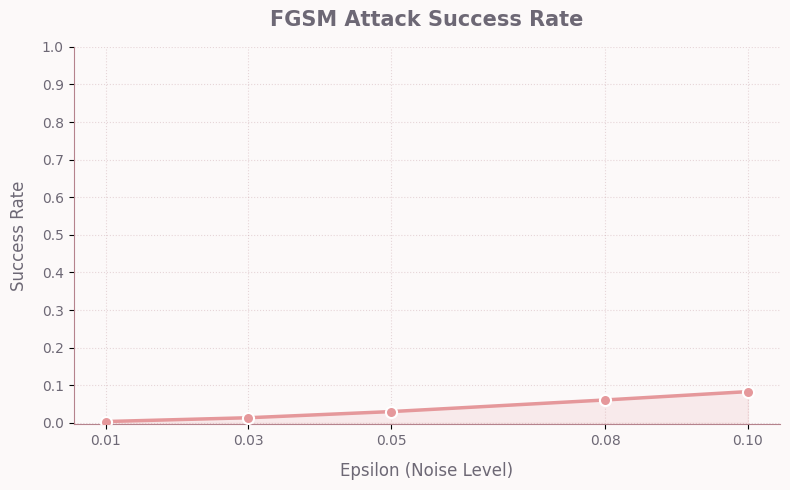

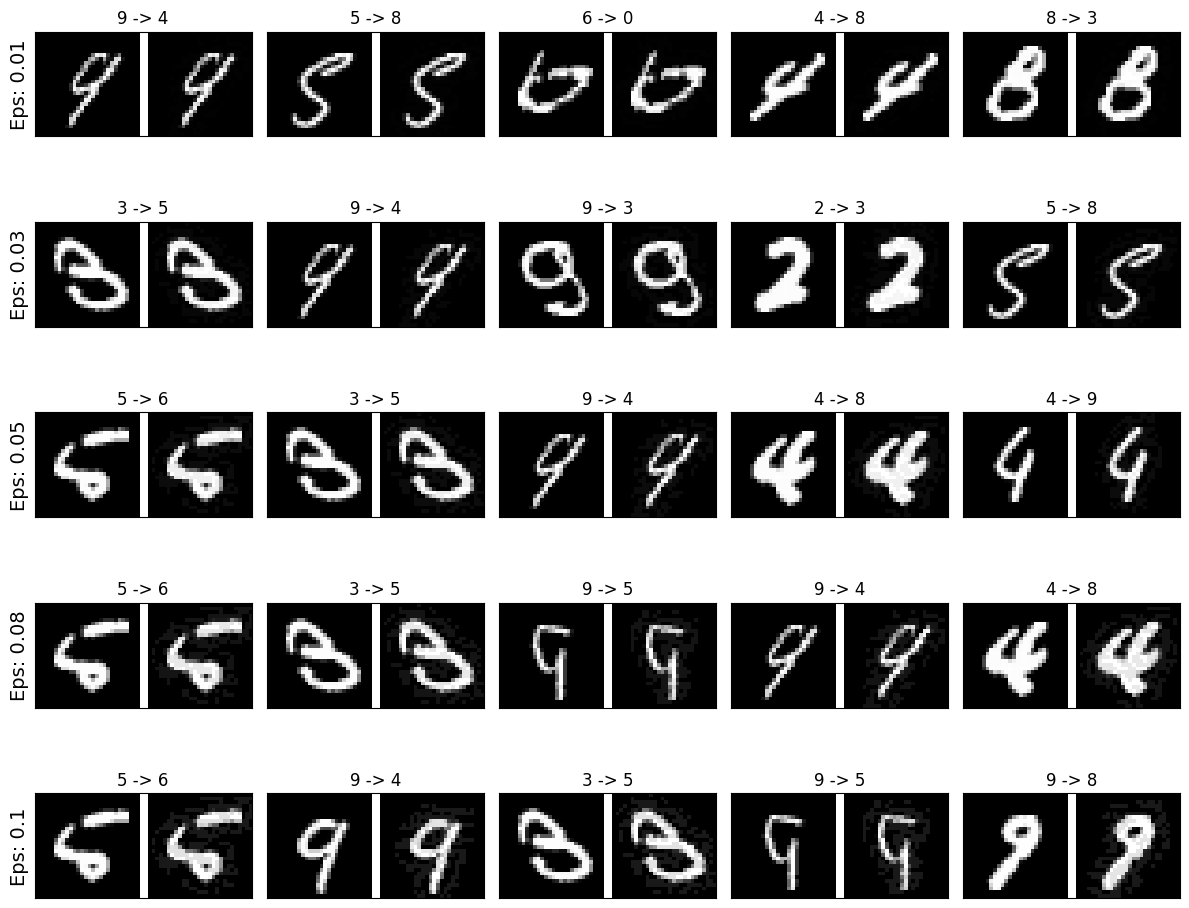


=== 提取的 ASR 數據 ===
{0.01: 0.0034343434343434343, 0.03: 0.013535353535353536, 0.05: 0.0298989898989899, 0.08: 0.06080808080808081, 0.1: 0.08303030303030302}

=== 成功提取對比圖素材 ===
原預測: 5, 攻擊後預測: 6
原圖 shape: (28, 28), 對抗樣本圖 shape: (28, 28)


In [ ]:
# 執行標準 FGSM 攻擊
epsilons = [0.01, 0.03, 0.05, 0.08, 0.1]
fgsm_attack = run_attack(FGSMAttack, model, epsilons, test_dataloader, device)

# 1. 測試：提取 ASR 數據 (供多模型圖表整合使用)
asr_data = fgsm_attack.get_asr_data()
print("\n=== 提取的 ASR 數據 ===")
print(asr_data)

# 2. 測試：提取對比圖素材 (供報告使用)
example_images = fgsm_attack.get_example_images(epsilon=0.1, num_images=1)
if example_images:
    init_p, adv_p, orig_img, adv_img = example_images[0]
    print(f"\n=== 成功提取對比圖素材 ===")
    print(f"原預測: {init_p}, 攻擊後預測: {adv_p}")
    print(f"原圖 shape: {orig_img.shape}, 對抗樣本圖 shape: {adv_img.shape}")

visualize_results(fgsm_attack)


--- Running SparseFGSMAttack ---


/home/karla/miniconda3/envs/fgsm_mnist/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epsilon: 0.01	Attack Success Rate = 1 / 9900 = 0.0001
Epsilon: 0.03	Attack Success Rate = 15 / 9900 = 0.0015
Epsilon: 0.05	Attack Success Rate = 37 / 9900 = 0.0037
Epsilon: 0.08	Attack Success Rate = 67 / 9900 = 0.0068
Epsilon: 0.1	Attack Success Rate = 88 / 9900 = 0.0089
Epsilon: 0.2	Attack Success Rate = 197 / 9900 = 0.0199
Epsilon: 0.3	Attack Success Rate = 350 / 9900 = 0.0354
Epsilon: 0.5	Attack Success Rate = 673 / 9900 = 0.0680


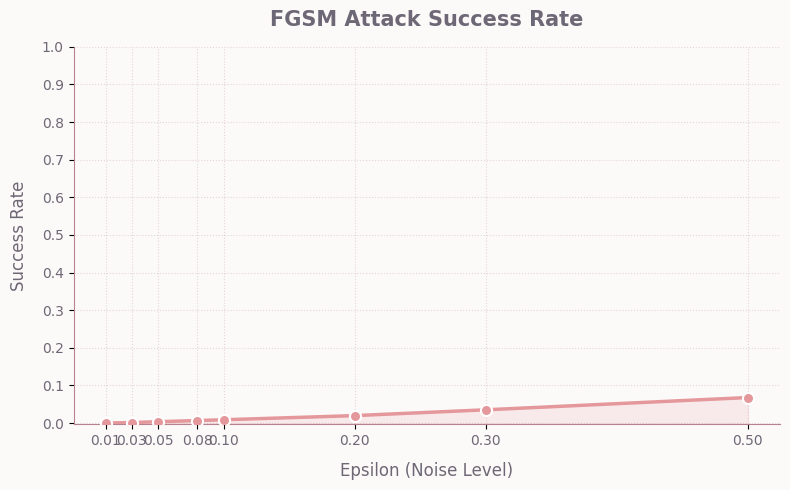

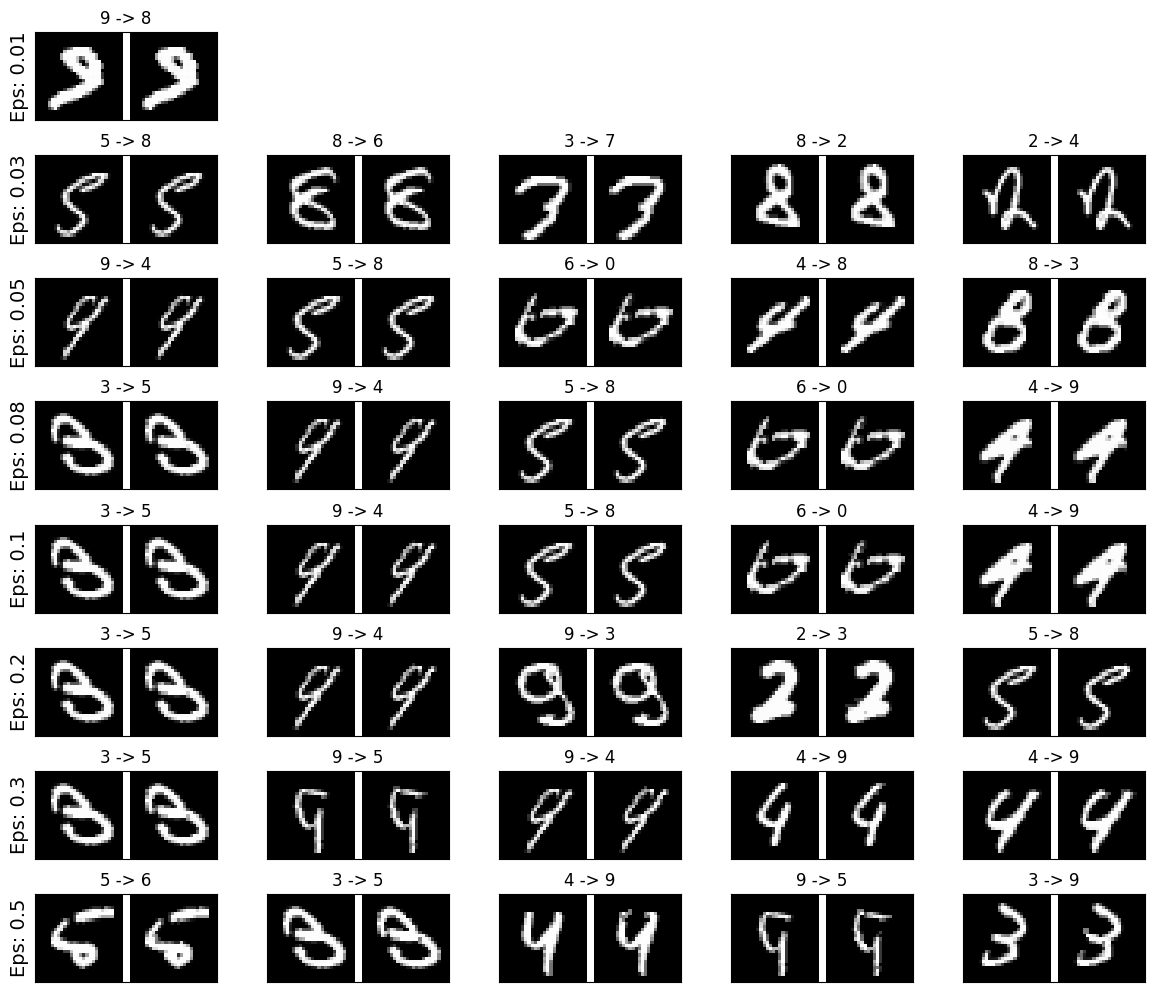

In [5]:
# 執行 Sparse FGSM 攻擊
sparse_epsilons = [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.5]
max_pixels = 15
sparse_attack = run_attack(SparseFGSMAttack, model, sparse_epsilons, test_dataloader, device, max_pixels=max_pixels)
visualize_results(sparse_attack)

In [ ]:
print("\n========== 對抗性微調 (Adversarial Fine-tuning) ==========")
if hasattr(fgsm_attack, 'retrain_images') and len(fgsm_attack.retrain_images) > 0:
    print(f"🚩 正在處理 {len(fgsm_attack.retrain_images)} 筆對抗樣本...")
    adv_images = torch.cat(fgsm_attack.retrain_images, dim=0)
    adv_labels = torch.cat(fgsm_attack.retrain_labels, dim=0)
    retrain_dataset = TensorDataset(adv_images, adv_labels)
    retrain_loader = DataLoader(retrain_dataset, batch_size=32, shuffle=True)

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    epochs = 5
    for epoch in range(epochs):
        current_loss = 0.0
        for images, labels in retrain_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            current_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {current_loss/len(retrain_loader):.4f}")
    print("✅ 對抗性微調完成！")
else:
    print("❌ 找不到誤判樣本。")



========== 對抗性微調 (Adversarial Fine-tuning) ==========
🚩 正在處理 1888 筆對抗樣本...


/home/karla/miniconda3/envs/fgsm_mnist/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epoch 1/5, Loss: 8.9568
Epoch 2/5, Loss: 7.2506
Epoch 3/5, Loss: 6.2235
Epoch 4/5, Loss: 4.9708
Epoch 5/5, Loss: 4.5407
✅ 對抗性微調完成！



=== 評估微調後的新模型 (FGSM) ===

--- Running FGSMAttack ---
Epsilon: 0.01	Attack Success Rate = 24 / 9913 = 0.0024
Epsilon: 0.03	Attack Success Rate = 97 / 9913 = 0.0098
Epsilon: 0.05	Attack Success Rate = 216 / 9913 = 0.0218
Epsilon: 0.08	Attack Success Rate = 580 / 9913 = 0.0585
Epsilon: 0.1	Attack Success Rate = 932 / 9913 = 0.0940


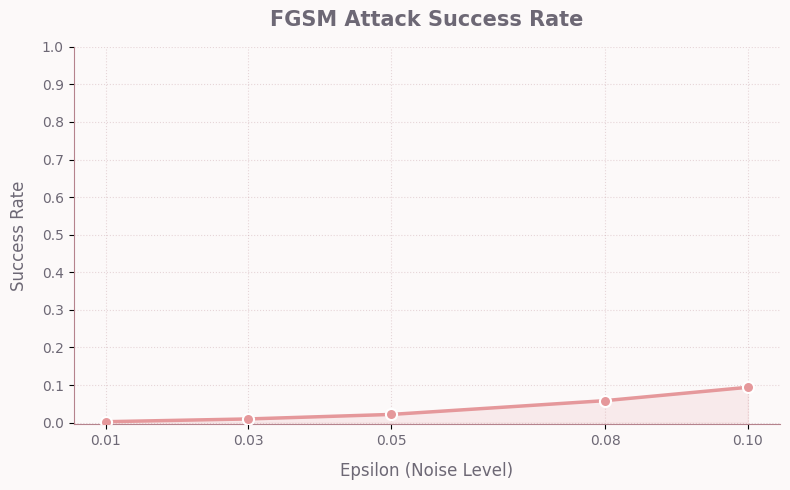

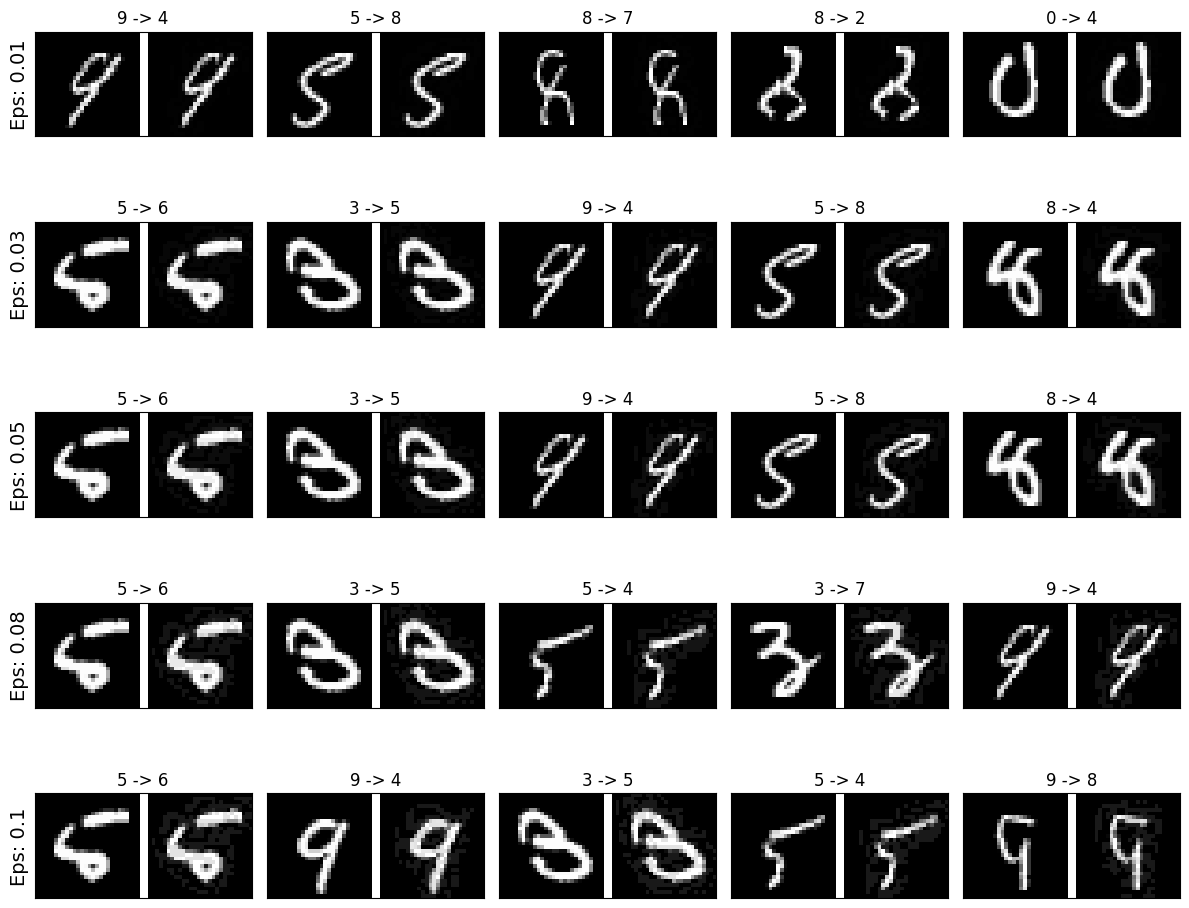

In [ ]:
print("\n=== 評估微調後的新模型 (FGSM) ===")
model.eval()
new_fgsm_attack = run_attack(FGSMAttack, model, epsilons, test_dataloader, device)
visualize_results(new_fgsm_attack)